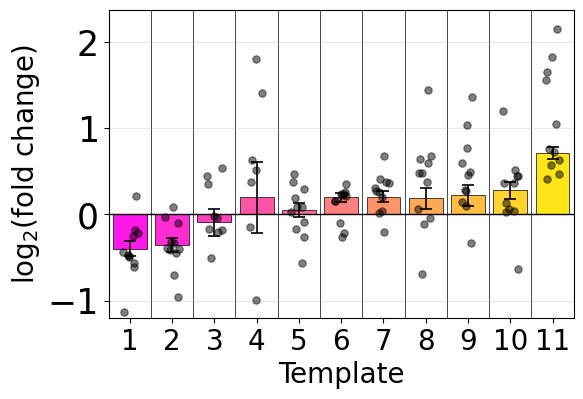

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# ── Load merged CSV ───────────────────────────────────────────────────────────
df = pd.read_csv('/Users/khunt/Desktop/Projects/emenecker_guadalupe_2023/Data/Figure_5/sequencing_data_all.csv')

# Templates 1-11
row_order = [
    'syn_LEA_1',
    'At2g46140_tile7',
    'TgL_8x',
    'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4',
    'A0A438HAK2',
    'Asyn_isoform_5',
    'A0A1U8F7A1',
    'Os_LEA_or6',
    'Os_LEA_or4',
    'A0A4D6M434',
]

name_to_num = {name: i + 1 for i, name in enumerate(row_order)}

# ── Weighted mean from DESeq2 rep columns ─────────────────────────────────────
lfc_cols = sorted([c for c in df.columns if c.startswith('log2FoldChange_rep')
                   and c[-1] in ['1', '2', '3']])
se_cols  = sorted([c for c in df.columns if c.startswith('lfcSE_rep')
                   and c[-1] in ['1', '2', '3']])

weights = 1 / (df[se_cols].values ** 2)
df['weighted_log2FC'] = np.nansum(weights * df[lfc_cols].values, axis=1) / np.nansum(weights, axis=1)
df['weighted_SE']     = 1 / np.sqrt(np.nansum(weights, axis=1))

# ── Raw log2FC dot columns (pair x rep) ───────────────────────────────────────
raw_lfc_cols = sorted([c for c in df.columns if c.startswith('log2FC_pair')])

# ── Build plot_df ─────────────────────────────────────────────────────────────
plot_data = []
for name in row_order:
    seq_id = f'original_sequence_-_{name}'
    match  = df[df['Sequence_ID'] == seq_id]
    if len(match) == 0:
        print(f"WARNING: no row found for {name}")
        continue

    row = match.iloc[0]

    # Raw dots: all pair x rep log2FC values, drop NaN (zero-filtered)
    raw_vals = [row[c] for c in raw_lfc_cols if pd.notna(row[c]) and np.isfinite(row[c])]

    plot_data.append({
        'name':            name,
        'template_num':    name_to_num[name],
        'weighted_log2FC': row['weighted_log2FC'],
        'weighted_SE':     row['weighted_SE'],
        'raw_fc':          raw_vals,
    })

plot_df = pd.DataFrame(plot_data)

# ── Colormap ──────────────────────────────────────────────────────────────────
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))

truncated_spring = truncate_colormap(plt.cm.spring, 0.10, 0.90)
colors = [truncated_spring(i / (len(plot_df) - 1)) for i in range(len(plot_df))]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
rng = np.random.default_rng(42)

# Bars: weighted mean + weighted SE
ax.bar(
    range(len(plot_df)),
    plot_df['weighted_log2FC'],
    yerr=plot_df['weighted_SE'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    error_kw=dict(ecolor='black', elinewidth=1.2, capsize=4, capthick=1.2),
    zorder=2
)

# Raw log2FC dots
for i, row in plot_df.iterrows():
    vals = row['raw_fc']
    if not vals:
        continue
    jitter = rng.uniform(-0.20, 0.20, size=len(vals))
    ax.scatter([i + j for j in jitter], vals,
               color='black', edgecolors='black', alpha=0.5,
               linewidths=0.8, s=28, zorder=5, clip_on=True)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=3)
for i in range(len(plot_df) + 1):
    ax.axvline(x=i - 0.5, color='black', linestyle='-', linewidth=0.5, zorder=1)

ax.set_ylabel('log$_2$(fold change)', fontsize=20)
ax.set_xlabel('Template', fontsize=20)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels([str(r) for r in plot_df['template_num']], fontsize=20)
ax.set_xlim(-0.5, len(plot_df) - 0.5)
ax.set_ylim(-1.2, None)
ax.set_yticks([-1, 0, 1.0, 2.0])
ax.tick_params(axis='y', labelsize=25)
ax.grid(True, axis='y', alpha=0.3, zorder=0)

plt.rcParams['svg.fonttype'] = 'none'
#fig.savefig('bar_chart_weighted_SE.svg', format='svg', bbox_inches='tight')
plt.show()